# Forecast–Price Feedback Loop — quickstart

*A library walkthrough for [`jrmst102/dynamic-price-forecast-loop`](https://github.com/jrmst102/dynamic-price-forecast-loop).*

A dynamic-pricing system sets a price from a **demand forecast**; that price
**reshapes the demand** the firm then observes; the observation is added back to
the training data and the forecaster is **retrained**. The loop can learn from its
own distorted evidence and settle at a *stable but wrong* price — the wrong
elasticity, the wrong markup.

This notebook drives that loop directly through the `fploop` API (no dashboard) and
walks through four things:

1. **One run** of the loop and what it logs.
2. **The problem** — the naive (greedy) baseline spirals away from the truth.
3. **The fix** — causal correction (control-function / 2SLS) tracks the truth.
4. **The regime question** — sweep the endogeneity strength λ and watch the gap open.

The world is **synthetic with a known true elasticity**, which is the whole point:
because the truth is set by the experimenter, residual estimation bias is directly
measurable. The synthetic worlds are calibrated to Dominick's grocery data elsewhere
in the repo; here we stay in pure simulation.

## Setup

**Running in Google Colab?** Just run the cell below — it clones the repo and installs
`fploop` into the runtime. **Running locally from the repo root** (after
`pip install -e .`)? The same cell detects that `fploop` is already importable and does
nothing. So this one notebook works in both places.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jrmst102/dynamic-price-forecast-loop/blob/main/examples/quickstart.ipynb)

In [1]:
# Colab / fresh-runtime bootstrap. Safe to run anywhere: a no-op if fploop is
# already installed (e.g. you launched from the repo root with `pip install -e .`).
import importlib.util, os, subprocess, sys

def _ensure(pkg, pip_target):
    if importlib.util.find_spec(pkg) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pip_target], check=True)
        return True
    return False

if importlib.util.find_spec("fploop") is None:
    REPO = "https://github.com/jrmst102/dynamic-price-forecast-loop.git"
    if not os.path.isdir("dynamic-price-forecast-loop"):
        subprocess.run(["git", "clone", "--depth", "1", REPO], check=True)
    # Core install is enough for this notebook; add ".[nn]" for the neural forecasters.
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "./dynamic-price-forecast-loop"], check=True)
    _ensure("matplotlib", "matplotlib")  # not a core fploop dep; needed for the plots
    print("Installed fploop from source. If the imports below fail, restart the "
          "runtime once (Runtime -> Restart) and re-run from here.")
else:
    _ensure("matplotlib", "matplotlib")
    print("fploop already available - no setup needed.")

fploop already available - no setup needed.


matplotlib (used for the plots) ships with Colab and most scientific
Python installs. Locally, `pip install matplotlib` if it is missing. The core `fploop`
install pulls NumPy / pandas / scikit-learn / Plotly and is **torch-free**; the `nn`,
`viz`, and `calib` extras are only needed for the neural forecasters, static figure
export, and the Dominick's calibration pipeline respectively.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from fploop.types import WorldConfig
from fploop.generators.linear_logit import LinearLogitWorld
from fploop.forecasters.gbt import GBTForecaster
from fploop.policies import (
    GreedyBaseline,            # Arm 0  — naive estimate-then-optimize
    ControlledVariancePricing, # Family A (exploration)  — vary the price
    ControlFunctionPolicy,     # Family B (causal, "twosls") — debias the estimate
    DecisionFocusedPolicy,     # Family C (decision-focused) — change the objective
)
from fploop.loop import run_simulation
from fploop.oracle import full_information_oracle
from fploop.metrics.regret import cumulative_regret
from fploop.metrics.bias import residual_elasticity_bias
from fploop.metrics.stability import performative_gap

# Consistent family colours (matching the dashboard).
C = {"baseline": "#6b7280", "exploration": "#0d9488",
     "causal": "#7c3aed", "decision_focused": "#f97316", "truth": "black"}

SEED = 0

## 1. One run of the loop

A run needs three pieces that plug together through fixed interfaces:

- a **world** (`LinearLogitWorld`) — the ground-truth demand curve plus the
  unobserved shock that contaminates the price;
- a **forecaster** (`GBTForecaster`) — gradient-boosted trees, retrained on the
  accumulating history;
- a **policy** — how the price is chosen from the forecast.

`run_simulation` turns the loop for `horizon` cycles and returns a `RunResult` whose
arrays are all aligned by pricing cycle. The key fields are `prices`,
`estimated_elasticity`, `true_elasticity`, `realized_revenue`, and the matching
`oracle_*` paths from a full-information benchmark.

In [3]:
config = WorldConfig(
    elasticity=-1.5,            # true demand elasticity (the thing to recover)
    endogeneity_strength=0.6,   # lambda: how strongly the shock leaks into price
    shock_std=0.2,              # demand-shock scale
    cost_shifter_std=0.15,      # exogenous cost variation (the instrument)
    horizon=200,
)

def run_policy(policy_cls, cfg=config, seed=SEED, **kw):
    # Run one closed-loop simulation with a fresh world and forecaster.
    world = LinearLogitWorld(cfg)
    policy = policy_cls(GBTForecaster(), rng=np.random.default_rng(seed), **kw)
    return run_simulation(world, policy, seed=seed)

baseline = run_policy(GreedyBaseline)

print("RunResult fields :", [f for f in vars(baseline) if not f.startswith("_")])
print("prices shape     :", baseline.prices.shape, "(horizon, n_products)")
print("true elasticity  :", float(baseline.true_elasticity.ravel()[-1]))
print("final est. elast.:", float(baseline.estimated_elasticity.ravel()[-1]))

RunResult fields : ['prices', 'observed_demand', 'realized_revenue', 'oracle_prices', 'oracle_revenue', 'estimated_elasticity', 'true_elasticity', 'metadata']
prices shape     : (200, 1) (horizon, n_products)
true elasticity  : -1.5
final est. elast.: -0.7476195946614123


## 2. The problem — the naive baseline spirals

`GreedyBaseline` is Arm 0: estimate the demand curve, optimize the price against the
point estimate, repeat. With endogeneity present (λ = 0.6), the shock that moves
demand also moves the price, so the forecaster reads a biased elasticity — and then
prices in a way that **manufactures data confirming that bias**.

Three views of the same failure, against the full-information oracle: the estimated
elasticity peels away from the truth, the price drifts off the oracle path, and
cumulative profit regret grows without bound. (The first ~15 cycles are warm-up
`NaN`s before the forecaster has fit — we drop them when plotting.)

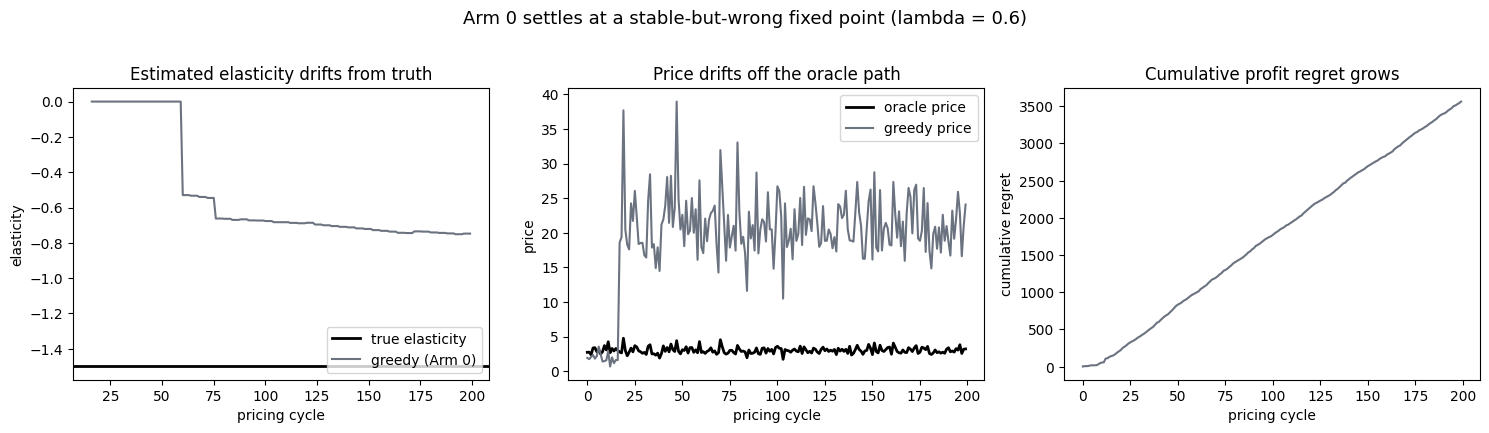

In [4]:
oracle = full_information_oracle(LinearLogitWorld(config), seed=SEED)
regret_b = cumulative_regret(baseline.realized_revenue, baseline.oracle_revenue)

cyc = np.arange(config.horizon)
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

ax[0].axhline(config.elasticity, color=C["truth"], lw=2, label="true elasticity")
ax[0].plot(cyc, baseline.estimated_elasticity.ravel(), color=C["baseline"], label="greedy (Arm 0)")
ax[0].set(title="Estimated elasticity drifts from truth",
          xlabel="pricing cycle", ylabel="elasticity")
ax[0].legend(loc="lower right")

ax[1].plot(cyc, oracle.oracle_prices.ravel(), color=C["truth"], lw=2, label="oracle price")
ax[1].plot(cyc, baseline.prices.ravel(), color=C["baseline"], label="greedy price")
ax[1].set(title="Price drifts off the oracle path", xlabel="pricing cycle", ylabel="price")
ax[1].legend(loc="upper right")

ax[2].plot(cyc, regret_b.ravel(), color=C["baseline"])
ax[2].set(title="Cumulative profit regret grows", xlabel="pricing cycle", ylabel="cumulative regret")

fig.suptitle("Arm 0 settles at a stable-but-wrong fixed point (lambda = 0.6)", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()

## 3. The fix — causal correction tracks the truth

`ControlFunctionPolicy` is the causal arm (registry name `"twosls"`, Family B). It
uses the exogenous cost shifter as an **instrument** to purge the endogeneity from
the elasticity estimate before pricing. Run it on the *same seed and shocks* as the
baseline and overlay the two.

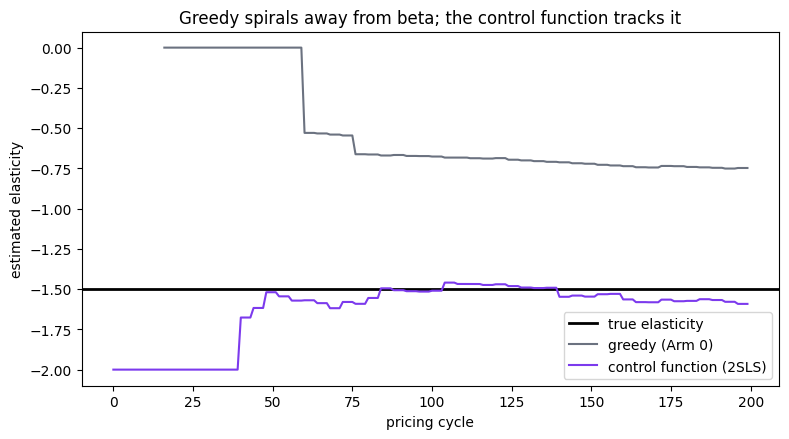

mean |bias|, 2nd half   greedy: 0.779   causal: 0.046


In [5]:
causal = run_policy(ControlFunctionPolicy)

def tail_abs_bias(res, frac=0.5):
    # Mean |estimated - true elasticity| over the final `frac` of (non-warmup) cycles.
    b = np.abs(residual_elasticity_bias(res.estimated_elasticity, res.true_elasticity)).ravel()
    b = b[~np.isnan(b)]
    return float(b[int(len(b) * (1 - frac)):].mean())

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.axhline(config.elasticity, color=C["truth"], lw=2, label="true elasticity")
ax.plot(cyc, baseline.estimated_elasticity.ravel(), color=C["baseline"], label="greedy (Arm 0)")
ax.plot(cyc, causal.estimated_elasticity.ravel(), color=C["causal"], label="control function (2SLS)")
ax.set(title="Greedy spirals away from beta; the control function tracks it",
       xlabel="pricing cycle", ylabel="estimated elasticity")
ax.legend(loc="lower right")
plt.show()

print(f"mean |bias|, 2nd half   greedy: {tail_abs_bias(baseline):.3f}   causal: {tail_abs_bias(causal):.3f}")

## 4. One representative per family

The interventions form a taxonomy by *where on the loop they act* (inspired by
AIF360's pre/in/post split):

| Family | Acts on | Representative here |
|---|---|---|
| Arm 0 — baseline | nothing | `GreedyBaseline` |
| A — exploration | the **price** | `ControlledVariancePricing` |
| B — causal | the **estimate** | `ControlFunctionPolicy` (2SLS) |
| C — decision-focused | the **objective** | `DecisionFocusedPolicy` |

Summary metrics on the same world: final cumulative regret, mean |bias| over the
second half, and the final performative gap (a price-path stability diagnostic —
smaller means a calmer, more converged path).

> **Caveat (from the repo README):** the exploration arm is still being repaired, so
> treat its numbers as illustrative, not as a basis for strong claims. The headline,
> well-validated comparison is **causal correction vs the naive baseline**.

In [6]:
families = [
    ("greedy (baseline)",        GreedyBaseline,            "baseline"),
    ("controlled-variance (A)",  ControlledVariancePricing, "exploration"),
    ("2SLS / control fn (B)",    ControlFunctionPolicy,     "causal"),
    ("decision-focused (C)",     DecisionFocusedPolicy,     "decision_focused"),
]

rows, runs = [], {}
for label, cls, fam in families:
    r = run_policy(cls)
    runs[label] = (r, fam)
    pgap = performative_gap(r.prices); pgap = pgap[~np.isnan(pgap)]
    rows.append((label,
                 float(cumulative_regret(r.realized_revenue, r.oracle_revenue).ravel()[-1]),
                 tail_abs_bias(r),
                 float(pgap[-1])))

print(f"{'policy':<26}{'final regret':>14}{'mean |bias|':>14}{'final p-gap':>14}")
print("-" * 68)
for label, reg, bias, pg in rows:
    print(f"{label:<26}{reg:>14.1f}{bias:>14.3f}{pg:>14.4f}")

policy                      final regret   mean |bias|   final p-gap
--------------------------------------------------------------------
greedy (baseline)                 3561.8         0.779        0.1451
controlled-variance (A)           3608.1         0.542        0.2158
2SLS / control fn (B)              257.1         0.046        0.1444
decision-focused (C)              3545.0         0.757        0.1451


## 5. The regime question — sweep λ

The interesting question is not *whether* correction helps once but *when*. Sweep the
endogeneity strength λ from 0 upward and compare the naive baseline against causal
correction by final cumulative regret.

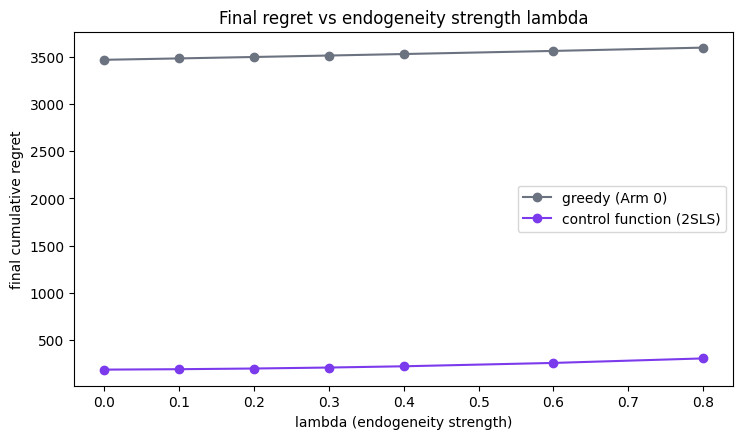

In [7]:
lambdas = [0.0, 0.1, 0.2, 0.3, 0.4, 0.6, 0.8]

def final_regret(cls, lam):
    cfg = WorldConfig(elasticity=-1.5, endogeneity_strength=lam, shock_std=0.2,
                      cost_shifter_std=0.15, horizon=200)
    r = run_policy(cls, cfg=cfg)
    return float(cumulative_regret(r.realized_revenue, r.oracle_revenue).ravel()[-1])

reg_greedy = [final_regret(GreedyBaseline, l) for l in lambdas]
reg_causal = [final_regret(ControlFunctionPolicy, l) for l in lambdas]

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.plot(lambdas, reg_greedy, "o-", color=C["baseline"], label="greedy (Arm 0)")
ax.plot(lambdas, reg_causal, "o-", color=C["causal"], label="control function (2SLS)")
ax.set(title="Final regret vs endogeneity strength lambda",
       xlabel="lambda (endogeneity strength)", ylabel="final cumulative regret")
ax.legend()
plt.show()

### Reading this honestly

In this **single-seed synthetic** world the causal arm stays low across the whole
range, while the naive baseline's regret climbs with λ. Note that the baseline also
struggles at λ ≈ 0 here — not from endogeneity but from *under-exploration*: greedy
starves itself of the price variation needed to identify a steep curve, and the
instrument happens to supply that variation too.

That is **not** the same as the repo's calibrated empirical claim. On the 24 elastic
Dominick's grocery categories, the verdict is: causal correction beats the naive
baseline in **23 of 24 categories at λ ≥ 0.4**, while at **λ ≈ 0 there is no clear
winner** and debiasing can even hurt (real grocery historically sits near λ ≈ 0). The
contribution is therefore forward-looking — as pricing becomes more algorithmic and
self-referential, λ rises and correction goes from optional to essential.

To reproduce that calibrated result (not just this toy sweep), use the CLI pipeline in
the README:

```bash
python scripts/run_calibrated.py \
  --arms greedy,controlled_variance,twosls \
  --lambda-grid 0,0.4,0.8 --seeds 0,1,2 --out results/sweep.csv
```

Everything in this notebook is seeded (`SEED = 0`); change the seed for a different
single realization, or average several seeds before drawing conclusions.